# News: scoring the tone of headlines, and fine-tuning the model that does it

**In short.** Each article's headline and summary is scored by a language model trained
on financial text. Part 1 measures how much news there is and how well the scores agree
with labelled headlines. Part 2 fine-tunes the model on headlines like ours and tests it
on ones it never saw.

Rebuild with `uv run python backend/scripts/build_notebooks.py 04_news`
(needs `uv sync --extra nlp`).

---

# Part 1. Tone

# News: tone, topics, and whether news moves price

**The questions.** What is the tone of the news on each market? What is it about?
And does a change in tone come before a price move, after it, or neither?

**The pipeline.**

1. Every stored article's headline and summary is scored by a language model
   (FinBERT), giving the probability that the tone is positive, negative, or neutral.
   The article's score is positive minus negative, from -1 to +1.
2. A second model assigns each article one topic from a fixed list.
3. Scores are averaged per day for each market.
4. Days with unusually strong tone are found, and the price around them is examined.

No article text appears in this notebook. Notebook 06 covers how the tone model was
fine-tuned and tested.

Rebuild with `uv run python backend/scripts/build_notebooks.py 05_news`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import func, select

from radar.analytics import event_study
from radar.db.models import ModelRegistry, NewsArticle, NewsSentiment, NewsSymbol, NewsTopic, SentimentAggregate
from radar.db.session import make_engine, session_scope
from radar.models import topics
from radar.pipelines import event_study as study_job
from radar.pipelines import sentiment as sentiment_job
from radar.universe import get_universe

plt.rcParams.update({"figure.figsize": (11, 3.4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
engine, universe = make_engine(), get_universe()
symbols = [a.symbol for a in universe.primary]
version = sentiment_job.active_version(engine)
topic_version = topics.version_of(topics.MODEL_ID)

with session_scope(engine) as session:
    scores = pd.read_sql(
        select(NewsSymbol.symbol, NewsArticle.created_at, NewsSentiment.score, NewsTopic.topic)
        .join(NewsArticle, NewsArticle.id == NewsSymbol.article_id)
        .join(NewsSentiment, NewsSentiment.article_id == NewsArticle.id)
        .outerjoin(NewsTopic, (NewsTopic.article_id == NewsArticle.id) & (NewsTopic.model_version == topic_version))
        .where(NewsSentiment.model_version == version, NewsArticle.duplicate_of.is_(None)),
        session.connection(),
    )
    daily = pd.read_sql(select(SentimentAggregate).where(SentimentAggregate.bucket == "1Day"), session.connection())
    accuracy = session.scalars(
        select(ModelRegistry).where(ModelRegistry.name == sentiment_job.MODEL_NAME, ModelRegistry.is_current)
    ).first().metrics
    studies = {s: study_job.current(session, s).metrics for s in symbols}
    inputs = {a.symbol: study_job.daily_inputs(session, a) for a in universe.primary}
scores["created_at"] = pd.to_datetime(scores["created_at"], utc=True)
print(f"tone model in use: {version}; {len(scores):,} article-market links scored")

tone model in use: finbert-radar-1; 107,095 article-market links scored


## 1. How much news there is

This decides everything that follows. Bitcoin and US stocks have many articles a day.
Gold has one or two, which is too few for some of the analysis, and the app says so.

In [2]:
coverage = pd.DataFrame(
    {
        a.symbol: {
            "measured from": a.news_start,
            "articles": int((scores["symbol"] == a.symbol).sum()),
            "articles per day": (scores["symbol"] == a.symbol).sum()
            / max((pd.Timestamp.now(tz="UTC") - pd.Timestamp(a.news_start, tz="UTC")).days, 1),
        }
        for a in universe.primary
    }
).T
coverage

,measured from,articles,articles per day
BTC/USD,2022-01-01,21428,12.329
GLD,2023-01-01,3300,2.403
SPY,2016-01-01,82367,20.959


## 2. How good is the tone model?

Measured on 200 headlines labelled separately, before any model output for them
existed. The labels were written by an AI model (Claude), not a person. The rival is
counting positive and negative words from a finance word list.

In [3]:
table = {"Tone model": accuracy["model"]}
if "baseline" in accuracy:
    table["Word counting"] = accuracy["baseline"]
if "topics" in accuracy:
    table["Topic model (7 topics)"] = accuracy["topics"]
print("labelled by:", accuracy["labelled_by"])
pd.DataFrame({k: {"headlines": v["n"], "accuracy": v["accuracy"], "macro F1": v["macro_f1"]} for k, v in table.items()}).T

labelled by: ['claude']


,headlines,accuracy,macro F1
Tone model,200.000,0.725,0.729
Word counting,200.000,0.515,0.502
Topic model (7 topics),200.000,0.600,0.489


In [4]:
pd.DataFrame(accuracy["by_symbol"]).T.rename(columns={"n": "headlines"})

,headlines,accuracy,macro_f1
GLD,40.000,0.650,0.661
SPY,80.000,0.725,0.714
BTC/USD,80.000,0.762,0.764


## 3. What the scores look like

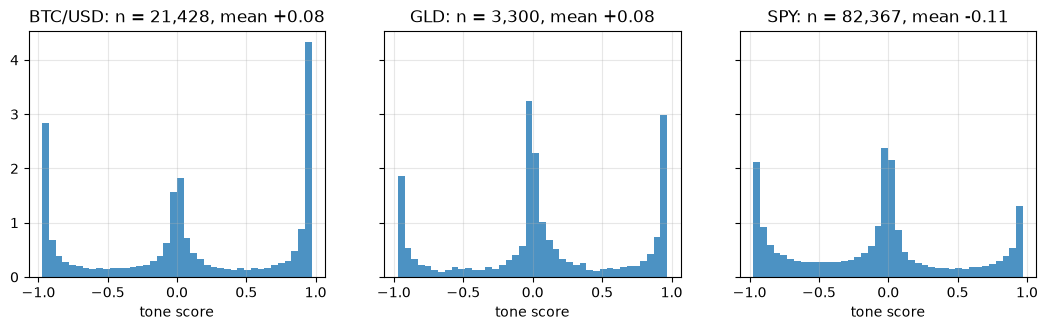

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, s in zip(axes, symbols):
    part = scores.loc[scores["symbol"] == s, "score"]
    ax.hist(part, bins=40, color="tab:blue", alpha=0.8, density=True)
    ax.set(title=f"{s}: n = {len(part):,}, mean {part.mean():+.2f}", xlabel="tone score")

Scores pile up near -1, 0, and +1 because the model is usually confident. That is
normal for this kind of model, and is why daily averages are used, not single scores.

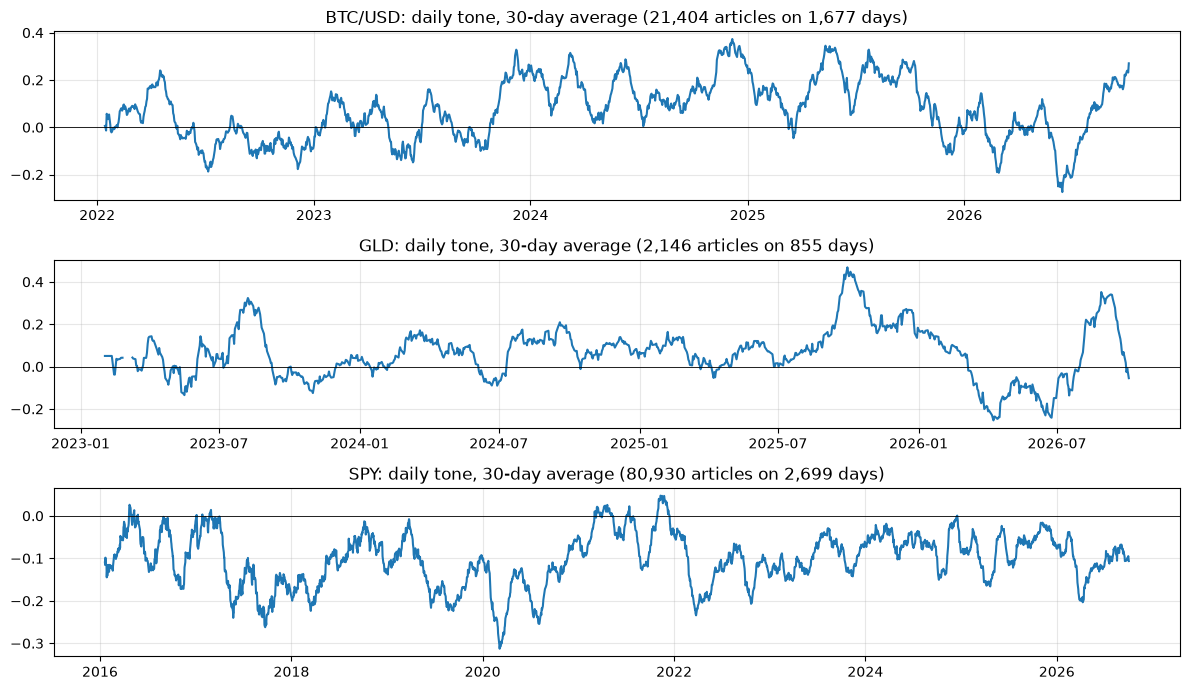

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False)
for ax, s in zip(axes, symbols):
    part = daily[daily["symbol"] == s].sort_values("ts").set_index("ts")
    smooth = part["score_mean"].rolling(30, min_periods=10).mean()
    ax.plot(smooth.index, smooth.values, color="tab:blue")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set(title=f"{s}: daily tone, 30-day average ({int(part['article_count'].sum()):,} articles on {int((part['article_count'] > 0).sum()):,} days)")
plt.tight_layout()

## What to take from this

- The tone model is good enough to say whether recent headlines read as positive or
  negative, and not good enough to trust on any single article.
- Tone is used to describe the news around a holding. It drives no forecast and no
  signal: a separate test found it does not improve the swings forecast, and a study of
  tone against price found that news mostly follows the move it describes (both are in
  `07_what_we_tested`).
- All articles come from one provider, and tone models misread sarcasm, negation, and
  headlines that only report a price.

---

# Part 2. Fine-tuning

# Fine-tuning the news sentiment model

**What this notebook shows.** RADAR scores the tone of each news article with FinBERT,
a language model already trained on financial sentences. Here that model is given a
few more passes over *our* kind of headlines, with labels, to see whether it gets
better at them, and the result is tested on headlines it never saw.

**How to read it.** Each section does one step of the pipeline, in the order the steps
must happen. The code calls the same modules the app uses (`radar.models.finetune`,
`radar.pipelines.finetune`), so nothing here is a copy that could drift.

**Honest limits, up front.**

- The labels were written by an AI model (Claude), not by a person. Fine-tuning on
  them teaches FinBERT to agree with that labeller. The test below measures agreement
  with the same labeller on unseen headlines, not agreement with human judgement.
- No article text is printed in this notebook. Headlines belong to the news provider.

Rebuild with `uv run python backend/scripts/build_notebooks.py 06_sentiment_finetuning`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from radar.db.session import make_engine, session_scope
from radar.models import classification, dataset, finetune, sentiment
from radar.models.lexicon import DEFAULT_PATH, Lexicon
from radar.pipelines import finetune as job
from IPython.display import display

from radar.pipelines.labels import load_labels

plt.rcParams.update({"figure.figsize": (9, 3.4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
engine = make_engine()

## 1. The labelled data

1,800 stored headlines were drawn at random, 720 each for Bitcoin and US stocks and
360 for gold (gold has far less news). Each was labelled positive, negative, or
neutral *for a financial reader*. The labels are stored in the repository by article
id only; the text is joined in from the database here.

In [2]:
with session_scope(engine) as session:
    data = job.with_text(session, job.load_training_labels())
    reference = job.with_text(session, load_labels())

print(f"{len(data):,} labelled headlines, labelled by: {sorted(set(data['labelled_by']))}")
pd.crosstab(data["symbol"], data["sentiment"], margins=True)

1,800 labelled headlines, labelled by: ['claude']


sentiment,negative,neutral,positive,All
symbol,,,,
BTC/USD,178,262,280,720
GLD,90,146,124,360
SPY,211,358,151,720
All,479,766,555,1800


## 2. Splitting without leakage

"Leakage" means testing a model on something it has, in effect, already seen. That
makes the score look better than it is. Three guards are used.

1. **Split by time, not at random.** The model trains on the oldest headlines, is
   tuned on later ones, and is tested on the newest. This is how it will be used: on
   news that arrives after it was trained.
2. **No near-duplicate headlines across parts.** Many headlines are templates that
   differ only in a number. Each headline is reduced to a key with numbers removed,
   and a key is allowed only once in the whole dataset.
3. **A separate test part, used once.** The validation part is for making choices
   (which epoch to keep). The test part is scored only after every choice is made.

In [3]:
parts = {name: data[data["split"] == name] for name in dataset.SPLITS}
summary = pd.DataFrame(
    {
        name: {
            "headlines": len(part),
            "earliest": part["created_at"].min().date(),
            "latest": part["created_at"].max().date(),
            "positive": (part["sentiment"] == "positive").mean(),
            "negative": (part["sentiment"] == "negative").mean(),
            "neutral": (part["sentiment"] == "neutral").mean(),
        }
        for name, part in parts.items()
    }
).T
summary

,headlines,earliest,latest,positive,negative,neutral
train,1261,2016-01-05,2025-05-09,0.286,0.277,0.437
validation,270,2025-05-09,2026-01-26,0.393,0.193,0.415
test,269,2026-01-26,2026-10-05,0.327,0.290,0.383


In [4]:
# The checks the pipeline runs before any training. Each raises an error if it fails.
job.check_dataset(data, reference)

keys = data["headline"].map(dataset.headline_key)
checks = {
    "articles appearing twice": int(data["article_id"].duplicated().sum()),
    "headline keys appearing twice": int(keys.duplicated().sum()),
    "articles shared with the 200-headline reference sample": len(
        set(data["article_id"]) & set(reference["article_id"])
    ),
    "headline keys shared with the reference sample": len(
        set(keys) & set(reference["headline"].map(dataset.headline_key))
    ),
    "train newer than validation": bool(
        parts["train"]["created_at"].max() >= parts["validation"]["created_at"].min()
    ),
    "validation newer than test": bool(
        parts["validation"]["created_at"].max() >= parts["test"]["created_at"].min()
    ),
}
pd.Series(checks, name="count (all must be 0 or False)").to_frame()

,count (all must be 0 or False)
articles appearing twice,0
headline keys appearing twice,0
articles shared with the 200-headline reference sample,0
headline keys shared with the reference sample,0
train newer than validation,False
validation newer than test,False


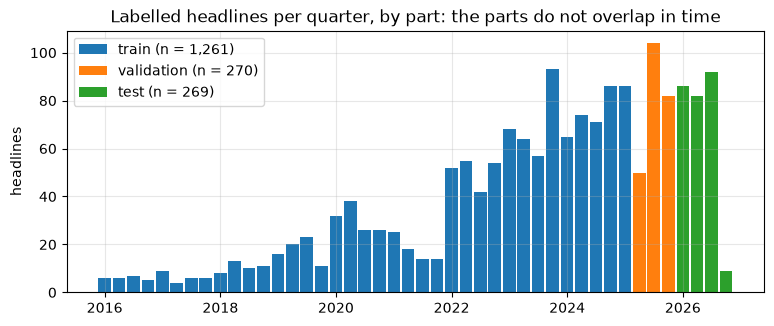

In [5]:
fig, ax = plt.subplots()
colours = {"train": "tab:blue", "validation": "tab:orange", "test": "tab:green"}
for name, part in parts.items():
    months = part["created_at"].dt.tz_localize(None).dt.to_period("Q").dt.to_timestamp()
    counts = months.value_counts().sort_index()
    ax.bar(counts.index, counts.values, width=80, color=colours[name], label=f"{name} (n = {len(part):,})")
ax.set(title="Labelled headlines per quarter, by part: the parts do not overlap in time", ylabel="headlines")
ax.legend();

## 3. Training

The settings are the standard ones for fine-tuning a BERT-sized model, chosen before
looking at any result: 4 passes over the training part, learning rate 0.00002, batches
of 16, a fixed random seed. After each pass the model is scored on the validation
part, and the pass with the best validation score is the one kept.

The training run itself is done by `uv run radar finetune`, which stores its record.
This notebook reads that record instead of retraining, so the numbers below are the
ones behind the model the app actually uses.

In [6]:
from sqlalchemy import select

from radar.db.models import ModelRegistry

with session_scope(engine) as session:
    row = session.scalars(
        select(ModelRegistry)
        .where(ModelRegistry.name == job.MODEL_NAME, ModelRegistry.is_current)
        .order_by(ModelRegistry.trained_at.desc())
    ).first()
    record, model_dir, trained_at = row.metrics, row.artefact_path, row.trained_at

training = record["training"]
print(f"trained {trained_at:%Y-%m-%d %H:%M} UTC from {training['base_model']}")
print(f"train {training['n_train']:,} / validation {training['n_validation']:,} headlines, "
      f"learning rate {training['learning_rate']}, batch {training['batch_size']}, seed {training['seed']}")
epochs = pd.DataFrame(training["epochs"]).set_index("epoch")
epochs

trained 2026-10-05 17:01 UTC from ProsusAI/finbert
train 1,261 / validation 270 headlines, learning rate 2e-05, batch 16, seed 13


,train_loss,validation_loss,validation_accuracy,validation_macro_f1
epoch,,,,
1,0.925,0.730,0.659,0.628
2,0.573,0.722,0.685,0.686
3,0.341,0.778,0.685,0.684
4,0.229,0.800,0.730,0.728


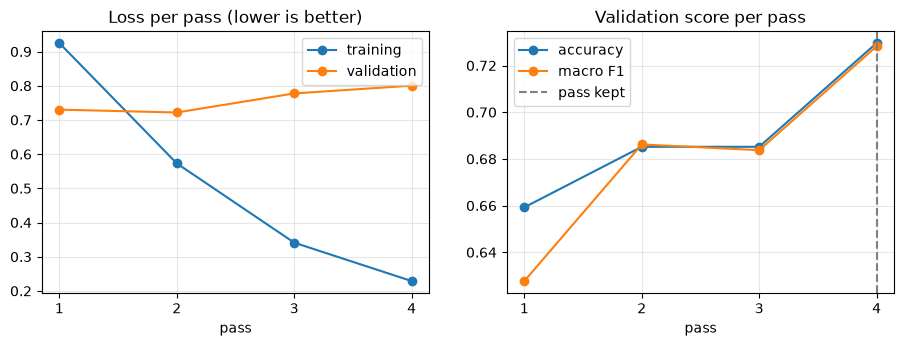

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(epochs.index, epochs["train_loss"], marker="o", label="training")
axes[0].plot(epochs.index, epochs["validation_loss"], marker="o", label="validation")
axes[0].set(title="Loss per pass (lower is better)", xlabel="pass", xticks=epochs.index)
axes[0].legend()
axes[1].plot(epochs.index, epochs["validation_accuracy"], marker="o", label="accuracy")
axes[1].plot(epochs.index, epochs["validation_macro_f1"], marker="o", label="macro F1")
axes[1].axvline(training["best_epoch"], color="grey", linestyle="--", label="pass kept")
axes[1].set(title="Validation score per pass", xlabel="pass", xticks=epochs.index)
axes[1].legend();

**Reading the curves.** Training loss keeps falling because the model is memorising
the training headlines. Validation loss is the honest one: when it stops falling and
turns up, further passes are fitting noise (overfitting). The pass kept is the one
with the best validation score, marked by the dashed line.

## 4. The test: headlines the model never saw

Now, and only now, the test part is used. Three methods label the same newest
headlines: the original FinBERT, the fine-tuned model, and a simple count of positive
and negative words from a finance word list.

In [8]:
test = parts["test"]
truth = test["sentiment"].tolist()
texts = test["text"].tolist()

base_scorer = sentiment.FinbertScorer()
tuned_scorer = sentiment.FinbertScorer(model_dir, finetune.MODEL_VERSION)
predictions = {
    "Original FinBERT": [sentiment.LABELS[i] for i in base_scorer.probabilities(texts).argmax(axis=1)],
    "Fine-tuned": [sentiment.LABELS[i] for i in tuned_scorer.probabilities(texts).argmax(axis=1)],
}
if DEFAULT_PATH.is_file():
    predictions["Word list"] = Lexicon.load().labels(texts)

reports = {name: classification.report(truth, labels, sentiment.LABELS) for name, labels in predictions.items()}
pd.DataFrame(
    {name: {"accuracy": r.accuracy, "macro F1": r.macro_f1, "headlines": r.n} for name, r in reports.items()}
).T

C:\Users\David\RADAR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 33462.53it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:  14%|█▍        | 28/201 [00:00<00:00, 248.90it/s]

Loading weights:  26%|██▋       | 53/201 [00:00<00:00, 222.39it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 812.36it/s]

,accuracy,macro F1,headlines
Original FinBERT,0.587,0.593,269.000
Fine-tuned,0.636,0.638,269.000
Word list,0.483,0.475,269.000


In [9]:
per_class = pd.concat(
    {
        name: pd.DataFrame([c.model_dump() for c in r.classes]).set_index("label")[["precision", "recall", "f1", "support"]]
        for name, r in reports.items()
    }
)
per_class

precision  recall    f1  support
                 label                                     
Original FinBERT positive      0.773   0.659 0.712       88
                 negative      0.477   0.679 0.561       78
                 neutral       0.566   0.456 0.505      103
Fine-tuned       positive      0.750   0.648 0.695       88
                 negative      0.618   0.603 0.610       78
                 neutral       0.573   0.650 0.609      103
Word list        positive      0.595   0.284 0.385       88
                 negative      0.505   0.667 0.575       78
                 neutral       0.427   0.515 0.467      103

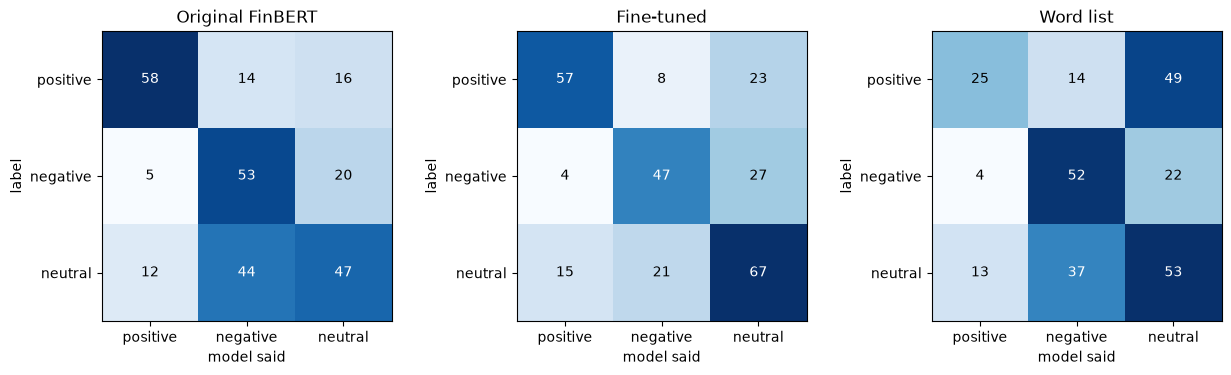

In [10]:
labels = list(sentiment.LABELS)
fig, axes = plt.subplots(1, len(predictions), figsize=(4.2 * len(predictions), 3.8))
for ax, (name, predicted) in zip(np.atleast_1d(axes), predictions.items()):
    table = pd.crosstab(
        pd.Categorical(truth, labels), pd.Categorical(predicted, labels), dropna=False
    ).to_numpy()
    ax.imshow(table, cmap="Blues")
    ax.set(xticks=range(3), yticks=range(3), xticklabels=labels, yticklabels=labels,
           xlabel="model said", ylabel="label", title=name)
    ax.grid(False)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, int(table[i, j]), ha="center", va="center",
                    color="white" if table[i, j] > table.max() / 2 else "black")
plt.tight_layout()

**Reading the grids.** Each row is what the label says; each column is what the model
said. The diagonal (top-left to bottom-right) is where they agree. A good model has
its large numbers on the diagonal.

## 5. Is the difference real?

A higher score on 269 headlines could be luck. McNemar's test looks only at the
headlines where the two models disagree about being right, and asks how likely such a
lopsided split would be if the models were really equal. A p-value under 0.05 is
taken as a real difference.

In [11]:
comparison = classification.mcnemar(truth, predictions["Original FinBERT"], predictions["Fine-tuned"])
adopted, reason = job.decide(reports["Original FinBERT"], reports["Fine-tuned"], comparison)
pd.Series(
    {
        "test headlines": comparison.n,
        "only the original was right": comparison.only_first_right,
        "only the fine-tuned model was right": comparison.only_second_right,
        "p-value": round(comparison.p_value, 6),
        "fine-tuned model adopted": adopted,
        "reason": reason,
    },
    name="value",
).to_frame()

,value
test headlines,269
only the original was right,20
only the fine-tuned model was right,33
p-value,0.098
fine-tuned model adopted,False
reason,difference_not_measurable


## 6. A second opinion: the earlier 200-headline sample

Before any fine-tuning, 200 other headlines were labelled to measure the original
model. None of them is in the training data (checked above), but their dates fall
inside the training period, so this is a weaker test than the one above. It is shown
because it was labelled separately and earlier.

In [12]:
reference_truth = reference["sentiment"].tolist()
reference_texts = reference["text"].tolist()
pd.DataFrame(
    {
        name: classification.report(
            reference_truth,
            [sentiment.LABELS[i] for i in scorer.probabilities(reference_texts).argmax(axis=1)],
            sentiment.LABELS,
        ).model_dump(include={"n", "accuracy", "macro_f1"})
        for name, scorer in (("Original FinBERT", base_scorer), ("Fine-tuned", tuned_scorer))
    }
).T

,n,accuracy,macro_f1
Original FinBERT,200.000,0.655,0.654
Fine-tuned,200.000,0.725,0.729


## 7. Does it hold for each market?

In [13]:
by_market = {}
for symbol, group in test.groupby("symbol"):
    index = [test.index.get_loc(i) for i in group.index]
    by_market[symbol] = {
        "headlines": len(group),
        **{
            name: classification.report(
                [truth[i] for i in index], [predicted[i] for i in index], sentiment.LABELS
            ).accuracy
            for name, predicted in predictions.items()
        },
    }
pd.DataFrame(by_market).T

,headlines,Original FinBERT,Fine-tuned,Word list
BTC/USD,129.000,0.643,0.682,0.481
GLD,83.000,0.542,0.554,0.422
SPY,57.000,0.526,0.649,0.579


## 8. A larger test, fixed in advance

The test in section 5 had 269 headlines. A 5-point gain on that few could easily be
luck, and the result was indeed "not measurable". Rather than adjust the model and try
again (which would turn the test into a tuning set), the **same saved model** was
scored on a fresh set of 700 headlines:

- all later than every training and validation headline;
- sharing no article and no headline key with anything labelled before;
- labelled before either model had scored them;
- with the adoption rule written down and committed before the labels existed.

Nothing was retrained and no setting was changed.

In [14]:
replication = record.get("replication")
if replication is None:
    print("The larger test has not been run yet.")
else:
    display(pd.DataFrame(
        {
            "Original FinBERT": {"accuracy": replication["base"]["accuracy"], "macro F1": replication["base"]["macro_f1"]},
            "Fine-tuned": {"accuracy": replication["fine_tuned"]["accuracy"], "macro F1": replication["fine_tuned"]["macro_f1"]},
            **({"Word list": {"accuracy": replication["baseline"]["accuracy"], "macro F1": replication["baseline"]["macro_f1"]}} if "baseline" in replication else {}),
        }
    ).T.assign(headlines=replication["n"]))
    comparison2 = replication["comparison"]
    display(pd.Series(
        {
            "headlines": replication["n"],
            "from": replication["first"],
            "to": replication["last"],
            "only the original was right": comparison2["only_first_right"],
            "only the fine-tuned model was right": comparison2["only_second_right"],
            "p-value": f"{comparison2['p_value']:.2g}",
            "first decision (269 headlines)": record.get("first_decision", {}).get("reason"),
            "decision now": record["reason"],
            "fine-tuned model adopted": record["adopted"],
        },
        name="value",
    ).to_frame())

,accuracy,macro F1,headlines
Original FinBERT,0.516,0.516,700
Fine-tuned,0.611,0.611,700
Word list,0.436,0.426,700


,value
headlines,700
from,2026-01-26
to,2026-10-05
only the original was right,45
only the fine-tuned model was right,112
p-value,8.9e-08
first decision (269 headlines),measurably_better
decision now,measurably_better
fine-tuned model adopted,True


,accuracy,"95% range, low","95% range, high"
Original FinBERT,0.516,0.479,0.553
Fine-tuned,0.611,0.575,0.647


,headlines,original,fine_tuned
GLD,140.000,0.514,0.586
SPY,280.000,0.471,0.571
BTC/USD,280.000,0.561,0.664


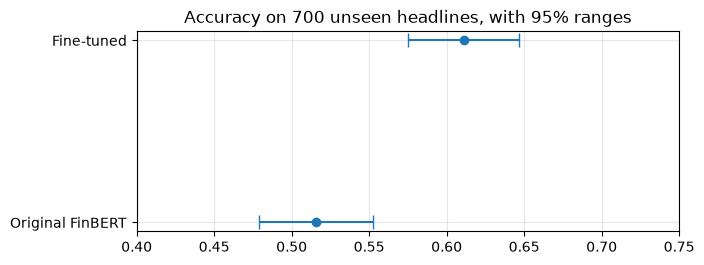

In [15]:
if replication is not None:
    from radar.models import evidence

    rows = {}
    for name, key in (("Original FinBERT", "base"), ("Fine-tuned", "fine_tuned")):
        low, high = evidence.share_interval(replication[key]["accuracy"], replication["n"])
        rows[name] = {"accuracy": replication[key]["accuracy"], "95% range, low": low, "95% range, high": high}
    ranges = pd.DataFrame(rows).T
    fig, ax = plt.subplots(figsize=(7, 2.6))
    ax.errorbar(
        ranges["accuracy"], ranges.index,
        xerr=[ranges["accuracy"] - ranges["95% range, low"], ranges["95% range, high"] - ranges["accuracy"]],
        fmt="o", capsize=5,
    )
    ax.set(title=f"Accuracy on {replication['n']} unseen headlines, with 95% ranges", xlim=(0.4, 0.75))
    display(ranges)
    display(pd.DataFrame(replication["by_symbol"]).T.rename(columns={"n": "headlines", "base": "original"}))

**Reading this.** When the two ranges do not overlap, the gain is not luck. Note what
the test does *not* say: an accuracy near 60% is still modest. Roughly four headlines
in ten get a different label from the labeller's. Section 9 looks at what kind of
mistakes those are.

## 9. What kind of mistakes?

Calling a mildly positive headline "neutral" is a small error. Calling a negative
headline "positive" is a serious one. The second kind is what would mislead a reader.

In [16]:
if replication is not None and "direction" in replication:
    display(pd.DataFrame(
        {"Original FinBERT": replication["direction_base"], "Fine-tuned": replication["direction"]}
    ).T.rename(columns={
        "n": "headlines", "opposite": "direction backwards", "opposite_rate": "share backwards",
        "both_polar": "both took a side", "same_direction": "same side when both did",
    }))

,headlines,direction backwards,both took a side,share backwards,same side when both did
Original FinBERT,700.000,79.000,318.000,0.113,0.752
Fine-tuned,700.000,49.000,302.000,0.070,0.838


## What to take from this

- The decision to use the fine-tuned model follows a rule fixed in advance: more
  accurate on unseen test headlines **and** a McNemar p-value under 0.05. The first
  test (section 5) was too small to tell; the larger one (section 8) decides.
- Accuracy around 60% on single headlines is modest. The app therefore shows the
  figure with its range beside the tone reading, and leans on daily averages of many
  articles, not on any one article's score.
- Agreement here is with one labeller. A person labelling the same headlines might
  disagree with some labels, and a model trained to match them inherits their habits.
- With a few hundred test headlines per market, the per-market figures in section 7
  are rough. Treat differences of a few points there as noise.